In [55]:
from google.colab import files
uploaded = files.upload()


Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
df=pd.read_csv('House Price Prediction Dataset.csv')

In [57]:
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [58]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [59]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [61]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [62]:
df.shape

(2000, 10)

In [69]:
x = df.drop(['Price', 'Area', 'Condition', 'Garage', 'Id'], axis=1)
y = df['Price']

In [70]:
list(x.columns)

['Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location']

In [71]:
y.head()

,Price
0,149919
1,424998
2,266746
3,244020
4,636056


In [73]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [82]:
x_train.dtypes

,0
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location_Rural,bool
Location_Suburban,bool
Location_Urban,bool


In [81]:
# One-hot encode the 'location' column
x_train = pd.get_dummies(x_train, columns=['Location'], drop_first=True)


In [83]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [88]:
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)


In [89]:
y_pred = model.predict(x_test)

In [92]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 78803720374.7547
R² Score: -0.012916542240713813


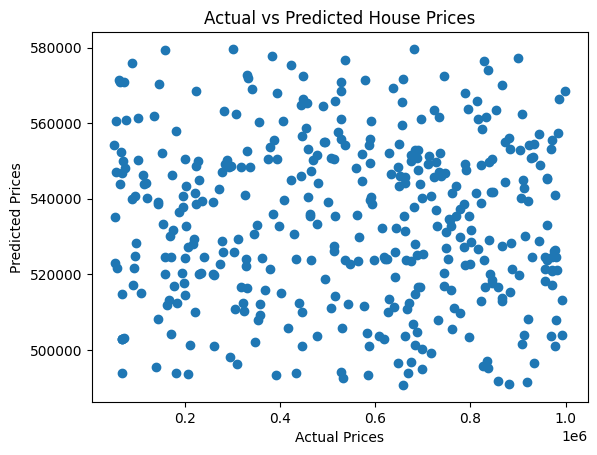

In [93]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [94]:
result = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(result.head(10))  # show first 10 predictions


   Actual Price  Predicted Price
0        514764    514284.733319
1        694256    543969.847105
2         66375    502988.691511
3        650243    554500.046601
4        223285    568618.293576
5        468127    550255.105017
6        513002    550558.177055
7        911525    544950.094309
8        723265    563441.601811
9        339416    569054.079971


In [98]:
coefficients = pd.DataFrame(model.coef_.reshape(-1, 1),
                            index=x_train.columns,
                            columns=['Coefficient'])

print(coefficients)


                    Coefficient
Bedrooms             142.331855
Bathrooms          -9895.037928
Floors             23944.316683
YearBuilt            107.847745
Location_Rural      2811.531334
Location_Suburban  13167.360904
Location_Urban    -12503.340714


In [100]:
from sklearn.preprocessing import StandardScaler # Feature Scaling

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [101]:
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)


In [102]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)  # degree=2 = quadratic
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)


In [103]:
model = LinearRegression()
model.fit(x_train_poly, y_train)
y_pred = model.predict(x_test_poly)


In [106]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(x_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [107]:
y_pred_poly = poly_model.predict(x_test)


In [108]:
from sklearn.metrics import mean_squared_error, r2_score

print("Polynomial Regression MSE:", mean_squared_error(y_test, y_pred_poly))
print("Polynomial Regression R²:", r2_score(y_test, y_pred_poly))


Polynomial Regression MSE: 79275014207.65448
Polynomial Regression R²: -0.01897439480566887


In [110]:
model = LinearRegression()
model.fit(x_train, y_train)  # train on raw x_train

y_pred_linear = model.predict(x_test)  # predict on raw x_test


In [111]:
y_pred_linear = model.predict(x_test)


In [112]:
print(x_train_scaled[:1])
print(x_train_poly.shape)  # should be (n_samples, 36)


[[ 0.68575834  1.31608835  1.24226027 -0.80867325 -0.5658021  -0.54942828
   1.74660611]]
(1600, 36)
